In [379]:
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import seaborn as sns
import subprocess

from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle

---

## Setup

In [380]:
def load_env(script_path: Path, keys):
    cmd = f'set -a; source "{script_path}" >/dev/null 2>&1; env'
    env_text = subprocess.check_output(["bash", "-lc", cmd], text=True)
    env_map = dict(
        line.split("=", 1)
        for line in env_text.splitlines()
        if "=" in line
    )
    for k in keys:
        if k in env_map:
            os.environ[k] = env_map[k]
    return {k: os.environ.get(k) for k in keys}


HOME = Path.home()
ENV_SETUP = HOME / "depth.sh"

KEYS = ["codedir", "wspace", "scriptdir"]
loaded = load_env(ENV_SETUP, KEYS)

# Build reusable Path variables for the rest of the notebook
CODEDIR = Path(os.environ["codedir"])
WSPACE = Path(os.environ["wspace"])
SCRIPTDIR = Path(os.environ["scriptdir"])

print("CODEDIR:", CODEDIR.is_dir())
print("WSPACE:", WSPACE.is_dir())
print("SCRIPTDIR:", SCRIPTDIR.is_dir())

CODEDIR: True
WSPACE: True
SCRIPTDIR: True


---

## Helper Functions

In [381]:
def smooth_metric(
    s: pd.Series,
    method: str = "rolling",   # "rolling" or "ewm"
    window: int = 25,
    alpha: float | None = None,
    min_periods: int = 1,
) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")

    if method == "rolling":
        return s.rolling(window=window, min_periods=min_periods).mean()

    if method == "ewm":
        # If alpha is not set, derive a reasonable one from window
        # (similar smoothness scale as rolling window).
        if alpha is None:
            alpha = 2 / (window + 1)
        return s.ewm(alpha=alpha, adjust=False, min_periods=min_periods).mean()

    raise ValueError("method must be 'rolling' or 'ewm'")

In [382]:
def plot_heatmap(ax, df, title, loss_range=None):
    heat = df.unstack("global_batch_size").sort_index()

    if loss_range is not None:
        vmin, vmax = loss_range
    else:
        vmin = np.nanmin(heat.to_numpy())
        vmax = np.nanmax(heat.to_numpy())

    # Log color mapping (all values must be > 0)
    norm = LogNorm(vmin=vmin, vmax=vmax)

    hm = sns.heatmap(
        heat,
        annot=True,
        fmt=".4f",
        cmap="mako_r",
        norm=norm,
        # cbar_kws={"label": Y_METRIC},
        ax=ax
    )

    # Exponential-style LR tick labels
    ax.set_yticklabels([f"{v:.0e}" for v in heat.index], rotation=0)

    # Box around global minimum-loss cell
    r, c = np.unravel_index(np.nanargmin(heat.to_numpy()), heat.shape)
    ax.add_patch(Rectangle((c, r), 1, 1, fill=False, edgecolor="red", linewidth=2.5))

    ax.set_xlabel("global_batch_size")
    ax.set_ylabel("max_lr")
    ax.set_title(f"{title}")

In [383]:
def plot_lr_lines(ax, df, title):
    # df is the same object you pass to plot_heatmap: MultiIndex Series
    # index levels: max_lr, global_batch_size
    line_df = df.unstack("global_batch_size").sort_index()  # rows=LR, cols=batch size

    lrs = line_df.index.to_numpy(dtype=float)

    # alpha map: higher LR -> more opacity
    lr_log = np.log10(lrs)
    if lr_log.max() == lr_log.min():
        alphas = np.ones_like(lr_log) * 0.8
    else:
        alphas = 0.4 + 0.6 * (lr_log - lr_log.min()) / (lr_log.max() - lr_log.min())

    x = line_df.columns.to_numpy(dtype=float)
    for lr, a, y in zip(lrs, alphas, line_df.to_numpy()):
        ax.plot(x, y, marker="o", linewidth=2, alpha=float(a), color="tab:orange", label=f"{lr:.0e}")

    ax.set_xscale("log", base=2)  # batch sizes are usually powers of 2
    ax.set_xlabel("global_batch_size")
    ax.set_ylabel("loss")
    ax.set_title(title)
    ax.grid(alpha=0.2)

    # optional compact legend
    ax.legend(title="max_lr", fontsize=8, title_fontsize=9, ncol=1, frameon=False)


def plot_bs_lines(ax, df, title):
    # df: MultiIndex Series with index levels ["max_lr", "global_batch_size"]
    line_df = df.unstack("global_batch_size").sort_index()  # rows=max_lr, cols=batch_size

    x = line_df.index.to_numpy(dtype=float)          # LR on x-axis
    batch_sizes = line_df.columns.to_numpy(dtype=float)

    # higher batch size -> higher opacity
    bs_log = np.log2(batch_sizes)
    if bs_log.max() == bs_log.min():
        alphas = np.full_like(bs_log, 0.8, dtype=float)
    else:
        alphas = 0.4 + 0.6 * (bs_log - bs_log.min()) / (bs_log.max() - bs_log.min())

    for bs, a in zip(batch_sizes, alphas):
        y = line_df[bs].to_numpy(dtype=float)
        ax.plot(x, y, marker="o", linewidth=2, alpha=float(a), color="tab:green", label=f"{int(bs)}")

    ax.set_xscale("log")  # LR is usually log-spaced
    ax.set_xlabel("max_lr")
    ax.set_ylabel("loss")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.legend(title="global_batch_size", fontsize=8, title_fontsize=9, frameon=False)

## Grid v1

In [384]:
BASE_PATH = WSPACE / "results/grid_collection/grid_v1/100M_AR32"
FILE_NAME = "aggregated_run_metrics.parquet"

In [385]:
Y_METRIC = "lm loss"
HYPERPARAMETERS = ["max_lr", "global_batch_size"]

In [386]:
SMOOTHING_WINDOW = 25

In [387]:
full_df = pd.read_parquet(BASE_PATH / FILE_NAME)
display(full_df.head(10))
print(full_df.shape)

,step,learning-rate,learning-rate vs samples,batch-size,batch-size vs samples,lm loss,lm loss vs samples,loss-scale,loss-scale vs samples,grad-norm,...,global_batch_size,weight_decay,lr_warmup_iters,lr_wsd_decay_iters,vocab_size,seed,total_params,embed_params,run_type,total_tokens
0,1,7.853403e-07,NaN,256.0,NaN,10.928690,NaN,1.0,NaN,8.804985,...,256,0.01,382,0,None,123456,118652928,51511296,lr3e-4_gb256_vanilla,524288
1,2,1.570681e-06,NaN,256.0,NaN,10.931339,NaN,1.0,NaN,8.805429,...,256,0.01,382,0,None,123456,118652928,51511296,lr3e-4_gb256_vanilla,1048576
2,3,2.356021e-06,NaN,256.0,NaN,10.930386,NaN,1.0,NaN,8.726339,...,256,0.01,382,0,None,123456,118652928,51511296,lr3e-4_gb256_vanilla,1572864
3,4,3.141361e-06,NaN,256.0,NaN,10.916890,NaN,1.0,NaN,8.840065,...,256,0.01,382,0,None,123456,118652928,51511296,lr3e-4_gb256_vanilla,2097152
4,5,3.926702e-06,NaN,256.0,NaN,10.891008,NaN,1.0,NaN,8.651213,...,256,0.01,382,0,None,123456,118652928,51511296,lr3e-4_gb256_vanilla,2621440
5,6,4.712042e-06,NaN,256.0,NaN,10.817505,NaN,1.0,NaN,8.344821,...,256,0.01,382,0,None,123456,118652928,51511296,lr3e-4_gb256_vanilla,3145728
6,7,5.497382e-06,NaN,256.0,NaN,10.770226,NaN,1.0,NaN,8.258095,...,256,0.01,382,0,None,123456,118652928,51511296,lr3e-4_gb256_vanilla,3670016
7,8,6.282723e-06,NaN,256.0,NaN,10.660599,NaN,1.0,NaN,7.821672,...,256,0.01,382,0,None,123456,118652928,51511296,lr3e-4_gb256_vanilla,4194304
8,9,7.068063e-06,NaN,256.0,NaN,10.619403,NaN,1.0,NaN,7.609506,...,256,0.01,382,0,None,123456,118652928,51511296,lr3e-4_gb256_vanilla,4718592
9,10,7.853403e-06,NaN,256.0,NaN,10.536858,NaN,1.0,NaN,7.376424,...,256,0.01,382,0,None,123456,118652928,51511296,lr3e-4_gb256_vanilla,5242880


(395791, 41)


In [388]:
# custom pre-processing
## grouping `vanilla`, `attnres_wd` and `attnres_nowd`

full_df["method"] = None
for k in ["vanilla", "attnres_wd", "attnres_nowd"]:
    full_df.loc[full_df["run_type"].str.contains(k), "method"] = k
full_df.drop("run_type", axis=1, inplace=True)

In [389]:
vanilla_df = full_df[full_df["method"] == "vanilla"].sort_values("step")
attnres_wd_df = full_df[full_df["method"] == "attnres_wd"].sort_values("step")
attnres_nowd_df = full_df[full_df["method"] == "attnres_nowd"].sort_values("step")

In [390]:
# Smoothing Y_METRICs

for _smoothing_col in ["lm loss"]:  # , "lm loss validation"]:
    for _df in [vanilla_df, attnres_wd_df, attnres_nowd_df]:
        _df[f"{_smoothing_col} smoothed"] = (
            _df.groupby(HYPERPARAMETERS, group_keys=False)[_smoothing_col]
            .transform(
                lambda x: smooth_metric(
                    x, 
                    method="rolling",  #  {`rolling`, `ewm`}
                    window=SMOOTHING_WINDOW
                )
            )
        )

In [391]:
print(f"vanilla_df shape: {vanilla_df.shape}")
print(f"attnres_wd_df shape: {attnres_wd_df.shape}")
print(f"attnres_nowd_df shape: {attnres_nowd_df.shape}")

vanilla_df shape: (133520, 42)
attnres_wd_df shape: (133520, 42)
attnres_nowd_df shape: (128751, 42)


In [392]:
Y_METRIC = "lm loss smoothed"

In [393]:
LOSS_RANGE = [np.inf, -np.inf]

for _df in [vanilla_df, attnres_wd_df, attnres_nowd_df]:
    result = (
        _df
        .sort_values("step")
        .groupby(HYPERPARAMETERS)[Y_METRIC]
        .last()
    )
    min_loss = result.min()
    max_loss = result.max()
    LOSS_RANGE[0] = min(LOSS_RANGE[0], min_loss)
    LOSS_RANGE[1] = max(LOSS_RANGE[1], max_loss)

print(f"LOSS_RANGE: {LOSS_RANGE}")

LOSS_RANGE: [np.float64(3.2050042724609376), np.float64(3.7109508895874024)]


<Figure size 640x480 with 0 Axes>

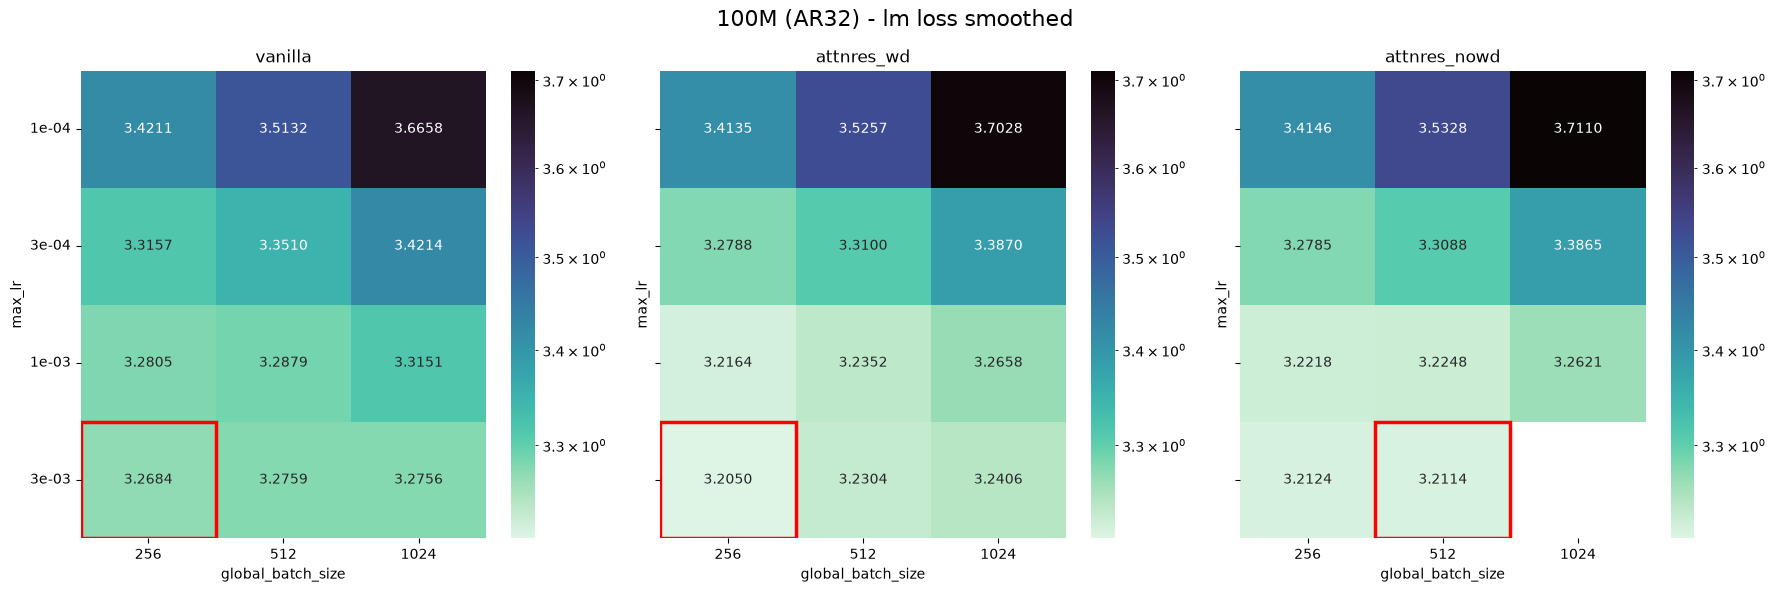

In [394]:
plt.clf()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (_df, _method) in enumerate(zip(
    [vanilla_df, attnres_wd_df, attnres_nowd_df], 
    ["vanilla", "attnres_wd", "attnres_nowd"]
)):
    ax = axes[i]
    result = (
        _df
        .sort_values("step")
        .groupby(HYPERPARAMETERS)[Y_METRIC]
        .last()
    )
    ax = plot_heatmap(ax, result, title=_method, loss_range=LOSS_RANGE)

plt.suptitle(f"100M (AR32) - {Y_METRIC}", fontsize=16)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

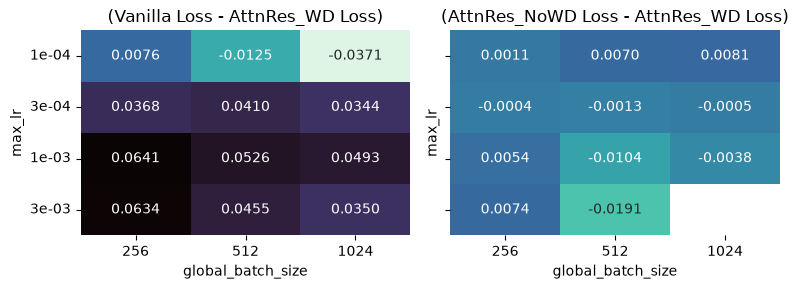

In [395]:
import matplotlib.colors as mcolors

plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

result1 = (
    vanilla_df.sort_values("step").groupby(HYPERPARAMETERS)[Y_METRIC].last()
    - attnres_wd_df.sort_values("step").groupby(HYPERPARAMETERS)[Y_METRIC].last()
)
result2 = (
    attnres_nowd_df.sort_values("step").groupby(HYPERPARAMETERS)[Y_METRIC].last()
    - attnres_wd_df.sort_values("step").groupby(HYPERPARAMETERS)[Y_METRIC].last()
)

heat1 = result1.unstack("global_batch_size").sort_index()
heat2 = result2.unstack("global_batch_size").sort_index()

# shared scale across both panels
vmin = np.nanmin([heat1.to_numpy().min(), heat2.to_numpy().min()])
vmax = np.nanmax([heat1.to_numpy().max(), heat2.to_numpy().max()])

# optional but great for difference plots: center colormap at 0
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

hm1 = sns.heatmap(
    heat1, annot=True, fmt=".4f", cmap="mako_r",
    norm=norm, cbar=False, ax=axes[0]
)
sns.heatmap(
    heat2, annot=True, fmt=".4f", cmap="mako_r",
    norm=norm, cbar=False, ax=axes[1]
)

axes[0].set_yticklabels([f"{v:.0e}" for v in heat1.index], rotation=0)
axes[1].set_yticklabels([f"{v:.0e}" for v in heat2.index], rotation=0)

axes[0].set_xlabel("global_batch_size")
axes[0].set_ylabel("max_lr")
axes[0].set_title("(Vanilla Loss - AttnRes_WD Loss)")

axes[1].set_xlabel("global_batch_size")
axes[1].set_ylabel("max_lr")
axes[1].set_title("(AttnRes_NoWD Loss - AttnRes_WD Loss)")

# reserve space at bottom for colorbar
# fig.subplots_adjust(bottom=0.2, wspace=0.25)

# # explicit colorbar axis: [left, bottom, width, height] in figure coords
# cax = fig.add_axes([0.20, 0.06, 0.60, 0.03])
# cbar = fig.colorbar(hm1.collections[0], cax=cax, orientation="horizontal", pad=-.55)
plt.tight_layout()

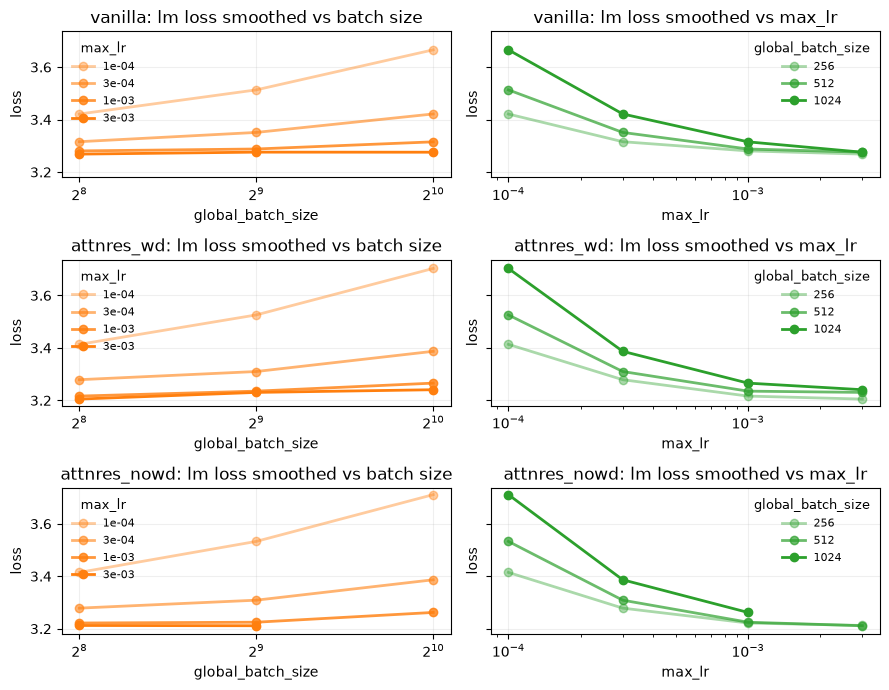

In [396]:
fig, ax = plt.subplots(3, 2, figsize=(9, 7), sharey=True)

for i, (_df, _method) in enumerate(zip(
    [vanilla_df, attnres_wd_df, attnres_nowd_df], 
    ["vanilla", "attnres_wd", "attnres_nowd"]
)):
    result = (
        _df
        .sort_values("step")
        .groupby(HYPERPARAMETERS)[Y_METRIC]
        .last()
    )
    plot_lr_lines(ax[i, 0], result, title=f"{_method}: {Y_METRIC} vs batch size")
    plot_bs_lines(ax[i, 1], result, title=f"{_method}: {Y_METRIC} vs max_lr")
plt.tight_layout()

In [397]:
# Y_METRIC = "lm loss validation smoothed"
Y_METRIC = "lm loss validation ppl"

In [398]:
LOSS_RANGE = [np.inf, -np.inf]

for _df in [vanilla_df, attnres_wd_df, attnres_nowd_df]:
    result = (
        _df
        .sort_values("step")
        .groupby(HYPERPARAMETERS)[Y_METRIC]
        .last()
    )
    min_loss = result.min()
    max_loss = result.max()
    LOSS_RANGE[0] = min(LOSS_RANGE[0], min_loss)
    LOSS_RANGE[1] = max(LOSS_RANGE[1], max_loss)

print(f"LOSS_RANGE: {LOSS_RANGE}")

LOSS_RANGE: [np.float64(24.273527145385742), np.float64(40.27725601196289)]


<Figure size 640x480 with 0 Axes>

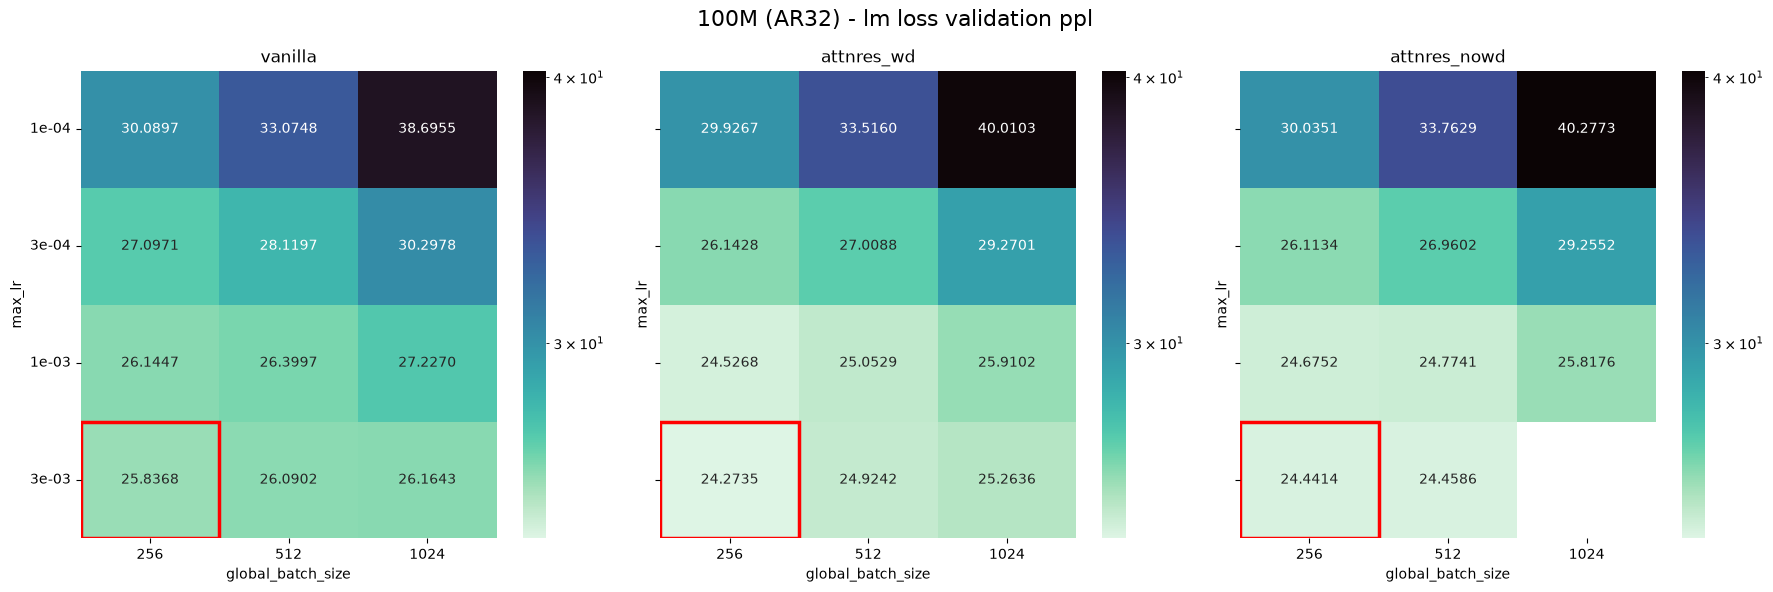

In [399]:
plt.clf()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (_df, _method) in enumerate(zip(
    [vanilla_df, attnres_wd_df, attnres_nowd_df], 
    ["vanilla", "attnres_wd", "attnres_nowd"]
)):
    ax = axes[i]
    result = (
        _df
        .sort_values("step")
        .groupby(HYPERPARAMETERS)[Y_METRIC]
        .last()
    )
    ax = plot_heatmap(ax, result, title=_method, loss_range=LOSS_RANGE)
plt.suptitle(f"100M (AR32) - {Y_METRIC}", fontsize=16)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

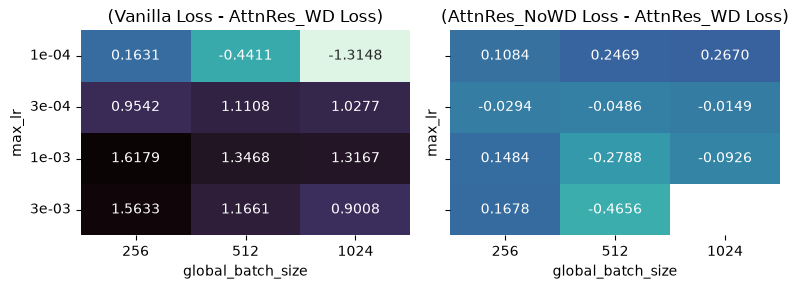

In [400]:
import matplotlib.colors as mcolors

plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

result1 = (
    vanilla_df.sort_values("step").groupby(HYPERPARAMETERS)[Y_METRIC].last()
    - attnres_wd_df.sort_values("step").groupby(HYPERPARAMETERS)[Y_METRIC].last()
)
result2 = (
    attnres_nowd_df.sort_values("step").groupby(HYPERPARAMETERS)[Y_METRIC].last()
    - attnres_wd_df.sort_values("step").groupby(HYPERPARAMETERS)[Y_METRIC].last()
)

heat1 = result1.unstack("global_batch_size").sort_index()
heat2 = result2.unstack("global_batch_size").sort_index()

# shared scale across both panels
vmin = np.nanmin([heat1.to_numpy().min(), heat2.to_numpy().min()])
vmax = np.nanmax([heat1.to_numpy().max(), heat2.to_numpy().max()])

# optional but great for difference plots: center colormap at 0
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

hm1 = sns.heatmap(
    heat1, annot=True, fmt=".4f", cmap="mako_r",
    norm=norm, cbar=False, ax=axes[0]
)
sns.heatmap(
    heat2, annot=True, fmt=".4f", cmap="mako_r",
    norm=norm, cbar=False, ax=axes[1]
)

axes[0].set_yticklabels([f"{v:.0e}" for v in heat1.index], rotation=0)
axes[1].set_yticklabels([f"{v:.0e}" for v in heat2.index], rotation=0)

axes[0].set_xlabel("global_batch_size")
axes[0].set_ylabel("max_lr")
axes[0].set_title("(Vanilla Loss - AttnRes_WD Loss)")

axes[1].set_xlabel("global_batch_size")
axes[1].set_ylabel("max_lr")
axes[1].set_title("(AttnRes_NoWD Loss - AttnRes_WD Loss)")

# reserve space at bottom for colorbar
# fig.subplots_adjust(bottom=0.2, wspace=0.25)

# # explicit colorbar axis: [left, bottom, width, height] in figure coords
# cax = fig.add_axes([0.20, 0.06, 0.60, 0.03])
# cbar = fig.colorbar(hm1.collections[0], cax=cax, orientation="horizontal", pad=-.55)
plt.tight_layout()

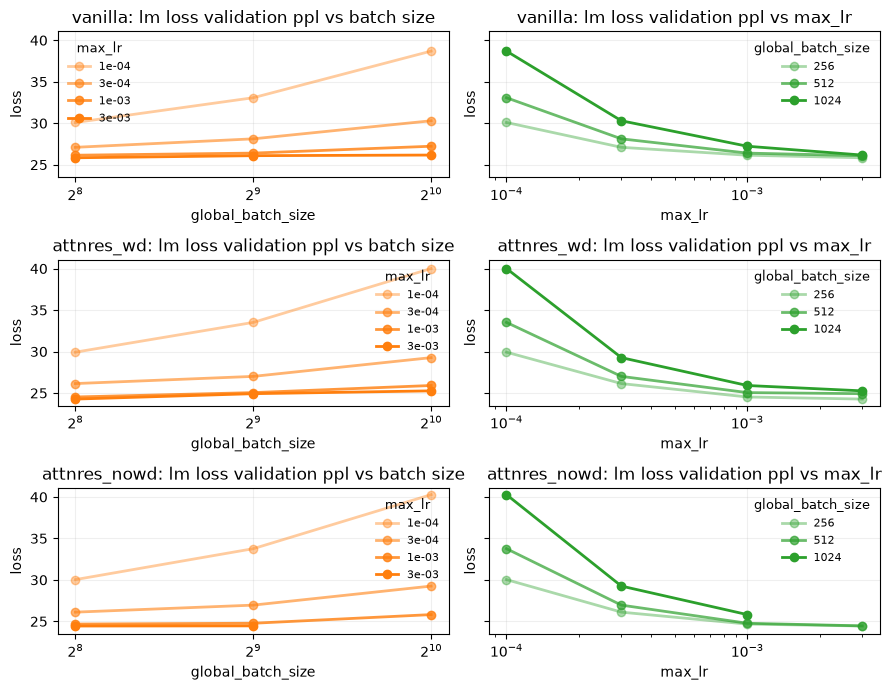

In [401]:
fig, ax = plt.subplots(3, 2, figsize=(9, 7), sharey=True)

for i, (_df, _method) in enumerate(zip(
    [vanilla_df, attnres_wd_df, attnres_nowd_df], 
    ["vanilla", "attnres_wd", "attnres_nowd"]
)):
    result = (
        _df
        .sort_values("step")
        .groupby(HYPERPARAMETERS)[Y_METRIC]
        .last()
    )
    plot_lr_lines(ax[i, 0], result, title=f"{_method}: {Y_METRIC} vs batch size")
    plot_bs_lines(ax[i, 1], result, title=f"{_method}: {Y_METRIC} vs max_lr")
plt.tight_layout()

---